In [3]:
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
print("Token chargé :", token[:7] + "...")

Token chargé : ghp_arJ...


In [4]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "aliciaandriantsara"
repo_name = "leaf-disease-transfer-learning"

repo_url = f"https://{token}@github.com/{username}/{repo_name}.git"

!git clone {repo_url}

Cloning into 'leaf-disease-transfer-learning'...
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 5 (delta 0), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (5/5), done.


In [5]:
%cd leaf-disease-transfer-learning/
!ls -la

/content/leaf-disease-transfer-learning
total 24
drwxr-xr-x 3 root root 4096 Sep 24 06:58 .
drwxr-xr-x 1 root root 4096 Sep 24 06:58 ..
drwxr-xr-x 8 root root 4096 Sep 24 06:58 .git
-rw-r--r-- 1 root root   63 Sep 24 06:58 .gitignore
-rw-r--r-- 1 root root  510 Sep 24 06:58 README.md
-rw-r--r-- 1 root root   48 Sep 24 06:58 requirements.txt


In [6]:
!git config --global user.email "aliciaandriantsara@gmail.com"
!git config --global user.name "aliciaandriantsara"

In [7]:
gitignore_content = """__pycache__/
*.pyc
.ipynb_checkpoints/
data/
*.h5
*.keras
.env
"""

requirements_content = """tensorflow
numpy
pandas
matplotlib
scikit-learn
"""

readme_content = """# Détection de maladies sur feuilles de plantes — Transfer Learning

## Contexte et objectif
Classificateur d'images capable de distinguer une feuille saine de feuilles atteintes de différentes maladies, à partir du dataset PlantVillage. Projet réalisé dans le cadre d'une candidature au Madagascar Data Science Hackathon 2026.

## Données
Dataset PlantVillage (Kaggle).

## Méthode
Transfer learning avec MobileNetV2 (pré-entraîné sur ImageNet).

## Statut
 Projet en cours de développement.
"""

with open("/content/leaf-disease-transfer-learning/.gitignore", "w") as f:
    f.write(gitignore_content)

with open("/content/leaf-disease-transfer-learning/requirements.txt", "w") as f:
    f.write(requirements_content)

with open("/content/leaf-disease-transfer-learning/README.md", "w") as f:
    f.write(readme_content)

print("Fichiers créés ")

Fichiers créés 


In [8]:
%cd /content/leaf-disease-transfer-learning/
!git add .
!git commit -m "Setup: structure de base du projet (.gitignore, requirements, README.md)"
!git push

/content/leaf-disease-transfer-learning
[main 5edd177] Setup: structure de base du projet (.gitignore, requirements, README.md)
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 400 bytes | 400.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/aliciaandriantsara/leaf-disease-transfer-learning.git
   02cfae4..5edd177  main -> main


In [9]:
import os
#module python qui permet d'interagir avec le system d'exploitation
from google.colab import userdata
#userdata permet de recuperer les informations secretes stockes dans google colab

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
#recuperer ton token kaggle depuis les secrets de colab et les mettre a une variable d'environnement
!pip install -q kaggle
#installer l'outil kaggle dans colab

!mkdir -p ~/.kaggle && echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token
#configurer l'authentification kaggle

#telecharger le dataset Plant Disease depuis kaggle
!kaggle datasets download -d emmarex/plantdisease -p /content/plantvillage --unzip


Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:38<00:00, 18.0MB/s]



In [10]:
import os

data_dir = "/content/plantvillage/PlantVillage"
# Si le dossier a un autre nom, on ajustera après avoir vu le résultat de la ligne suivante :
print(os.listdir("/content/plantvillage"))

['PlantVillage', 'plantvillage']


In [11]:
data_dir = "/content/plantvillage/PlantVillage"
classes = os.listdir(data_dir)
#recuperer la liste de tous les fichiers et dossiers qui se trouvent dans datadir
print(f"Nombre de classes : {len(classes)}")
print(classes)

Nombre de classes : 15
['Tomato_Septoria_leaf_spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Late_blight', 'Pepper__bell___healthy', 'Tomato_Early_blight', 'Tomato__Tomato_mosaic_virus', 'Tomato_Bacterial_spot', 'Pepper__bell___Bacterial_spot', 'Tomato_Leaf_Mold', 'Potato___Late_blight', 'Tomato_healthy', 'Tomato__Target_Spot', 'Potato___healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Potato___Early_blight']


In [12]:
for c in classes:
    n = len(os.listdir(os.path.join(data_dir, c)))
    print(f"{c} : {n} images")

Tomato_Septoria_leaf_spot : 1771 images
Tomato__Tomato_YellowLeaf__Curl_Virus : 3209 images
Tomato_Late_blight : 1909 images
Pepper__bell___healthy : 1478 images
Tomato_Early_blight : 1000 images
Tomato__Tomato_mosaic_virus : 373 images
Tomato_Bacterial_spot : 2127 images
Pepper__bell___Bacterial_spot : 997 images
Tomato_Leaf_Mold : 952 images
Potato___Late_blight : 1000 images
Tomato_healthy : 1591 images
Tomato__Target_Spot : 1404 images
Potato___healthy : 152 images
Tomato_Spider_mites_Two_spotted_spider_mite : 1676 images
Potato___Early_blight : 1000 images


In [13]:
#classe : categorie que tu veux que ton model apprenne a reconnaitre
#1 classe correspoond a une combinaison de plante + etat de sante
#15 classes differentes
#1 dossier = 1 classe
#label reponse correct associe a une donnee
#exemple tomate_001.jpg -> tomate_malade
#le nom du dossier est l'etiquette label de tous les images qu'il contient
#un modele ne comprends que des chiffres
#charger les donnees avec image_dataset_from_directory(keras) il va automatiquement
#parcourir chaque sous dossier
#associer toutes les images qu'il contient au nom du dossier comme etiquette
#transformer ces etiquettes textes en nombre tomate_healthy-> classe 0 car un modele
#ne comprend que des chiffres
#capacite de classification multiclasses

In [14]:
#code pour creer le sous ensemble

import shutil
#permet de manipuler les fichiers et les dossiers

selected_classes = [
    "Tomato_healthy",
    "Tomato_Bacterial_spot",
    "Tomato_Late_blight",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite"
]

#choix de 5 classes uniquement a mettre dans ce sous-dossier
subset_dir = "/content/plantvillage_subset"
os.makedirs(subset_dir, exist_ok=True)

for c in selected_classes:
    #construire les chemins
    src = os.path.join(data_dir, c)
    dst = os.path.join(subset_dir, c)
    #copier un dossier entier avec son contenu
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print(f"{c} copié ")

print("\nSous-ensemble prêt dans :", subset_dir)

Tomato_healthy copié 
Tomato_Bacterial_spot copié 
Tomato_Late_blight copié 
Tomato_Septoria_leaf_spot copié 
Tomato_Spider_mites_Two_spotted_spider_mite copié 

Sous-ensemble prêt dans : /content/plantvillage_subset


In [15]:
#split train/validation/test

import os
import shutil
import random
#opreation aleatoire melanger les images

random.seed(42)  # pour reproductibilité
#fixer le hasard pour toujours obtenir le meme melange des images

subset_dir = "/content/plantvillage_subset"
split_dir = "/content/plantvillage_split"

splits = {"train": 0.70, "val": 0.15, "test": 0.15}

for split_name in splits:
    for c in selected_classes:
        os.makedirs(os.path.join(split_dir, split_name, c), exist_ok=True)
        #creation de l'arborescence ou les images sont reparties en train valid test

for c in selected_classes:
    class_dir = os.path.join(subset_dir, c)
    images = os.listdir(class_dir)
    random.shuffle(images)
    #melanger aleatoirement les listes des images


    n = len(images)
    #calculer combien vont ou ?
    n_train = int(n * splits["train"])
    n_val = int(n * splits["val"])

    train_imgs = images[:n_train]
    #prendre les 70% premieres images de la liste melangees
    val_imgs = images[n_train:n_train + n_val]
    test_imgs = images[n_train + n_val:]

    for img_name, split_name in [(i, "train") for i in train_imgs] + \
                                  [(i, "val") for i in val_imgs] + \
                                  [(i, "test") for i in test_imgs]:
        src = os.path.join(class_dir, img_name)
        dst = os.path.join(split_dir, split_name, c, img_name)
        shutil.copyfile(src, dst)

    print(f"{c} : {len(train_imgs)} train / {len(val_imgs)} val / {len(test_imgs)} test")

print("\n Split terminé dans :", split_dir)

Tomato_healthy : 1113 train / 238 val / 240 test
Tomato_Bacterial_spot : 1488 train / 319 val / 320 test
Tomato_Late_blight : 1336 train / 286 val / 287 test
Tomato_Septoria_leaf_spot : 1239 train / 265 val / 267 test
Tomato_Spider_mites_Two_spotted_spider_mite : 1173 train / 251 val / 252 test

 Split terminé dans : /content/plantvillage_split


In [16]:
#charger les donnees avec keras image_dataset_from_directory
#transformer les fichiers presents en un dataset tensorflow que le reseau de neurone peut recevoir
import tensorflow as tf
import os

IMG_SIZE = (224, 224)
#redimensionnement des images
BATCH_SIZE = 32
#le modele va traiter 32 images a la fois au lieu de charger tous les images en meme temps

split_dir = "/content/plantvillage_split"

#demande a tensorflow de lire les images du dossier train et de creer un dataset utilisable pour le model
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    #[0,0,1] [0,1,0], [1, 0, 0]
    shuffle=True,
    #melange les images de test
    seed=42
    #sans seed le melange peut changer a chaque execution
    #avec seed on peut garder le meme melange a chaque execution pour des donnees identiques
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
    #ne melange pas les images
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
#recuperer les noms des classes trouves dans les datasets
print("Classes détectées :", class_names)

Found 6349 files belonging to 5 classes.
Found 1359 files belonging to 5 classes.
Found 1366 files belonging to 5 classes.
Classes détectées : ['Tomato_Bacterial_spot', 'Tomato_Late_blight', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_healthy']


In [17]:
#data augmentation
#creer artificiellemnt des variantes de tes images existantes pour avoir plus de diversite dans les donnees d'entrainement


# Sequential on cree une sequence de transformation d'images
#les transformations seront appliquees les unes apres les autres

# Couche de data augmentation — appliquée uniquement pendant l'entraînement
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    #retourne l'image horizontalement
    tf.keras.layers.RandomRotation(0.15),
    #tourne l'image aleatoirement avec un angle 0.15 * 360
    tf.keras.layers.RandomZoom(0.15),
    #zoome aleatoirement sur l'image environ de 15%
], name="data_augmentation")

# Preprocessing spécifique à MobileNetV2 (remplace la normalisation manuelle)
#preparation des pixels de tes images avant de les donner a MobileNetV2
#les pixels seront transformes dans un intervalle de -1 a 1
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

#rendre l'entrainement plus rapide et plus fluide
#preparer les donnees a l'avance
# Optimisation de la lecture des données
AUTOTUNE = tf.data.AUTOTUNE
#choisir automatiquement les parametres permettant de charger les donnees efficacement
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
#cache conserve les donnees chargees
#shuffle melanger les images du dataset d'entrainement
#preparer les prochaines donnees pendant que le model travaille sur les donnees actuelles
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(" Augmentation et preprocessing prêts")

 Augmentation et preprocessing prêts


In [18]:
%cd /content/leaf-disease-transfer-learning
!git add .
!git commit -m "Data: augmentation et preprocessing MobileNetV2 prepares"
!git push

/content/leaf-disease-transfer-learning
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
!find /content/drive/MyDrive -name "notebook_classification.ipynb"

/content/drive/MyDrive/Colab Notebooks/notebook_classification.ipynb


In [21]:
#A refaire manomboka eto rehefa mahavita etape katrany amin'ny push
import shutil

notebook_path = "/content/drive/MyDrive/Colab Notebooks/notebook_classification.ipynb"  # ajuste selon le résultat du find
destination = "/content/leaf-disease-transfer-learning/notebook_classification.ipynb"

shutil.copy(notebook_path, destination)
print(" Notebook copié dans le repo")

✅ Notebook copié dans le repo


In [22]:
%cd /content/leaf-disease-transfer-learning
!git add .
!git commit -m "Data: augmentation et preprocessing MobileNetV2 prepares"
!git push

/content/leaf-disease-transfer-learning
[main 15b672b] Data: augmentation et preprocessing MobileNetV2 prepares
 1 file changed, 1 insertion(+)
 create mode 100644 notebook_classification.ipynb
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 6.65 KiB | 6.65 MiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/aliciaandriantsara/leaf-disease-transfer-learning.git
   5edd177..15b672b  main -> main


In [23]:
#MobileNetV2 a deja appris a reconnaitre des caracteristiques visuelles
# transfer learning tranferer les connaissances acquises par une modele sur une premiere tache vers une nouvelle tache

#Construction du modele par transfer learning

# Nombre de classes (5 dans notre cas)
num_classes = len(class_names)

# Charger MobileNetV2 pré-entraîné sur ImageNet, sans la couche de classification finale
#Charger MobileNetV2 deja entraine
#servira de base au nouvel model
#charger l'architecture MobileNetV2 reseau de neurone specialise dans la vision par ordinateur
base_model = tf.keras.applications.MobileNetV2(
    #taille de l'image + canaux de couleur
    input_shape=(224, 224, 3),
    #retire la partie finale de la classification de MobileNetV2
    include_top=False,       # on retire le classifieur ImageNet (1000 classes)
    #charge le poids que MobileNetV2 a deja appris avec le dataset imagenet
    weights="imagenet"
)

# Geler les couches du modèle de base : on ne les entraîne pas pour l'instant
base_model.trainable = False

# Construire le modèle complet
#definir la forme des images que le modele va recevoir en entree
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)           # augmentation (actif seulement en entraînement)
x = preprocess_input(x)                 # normalisation spécifique MobileNetV2
x = base_model(x, training=False)       # extraction de features (gelé)
#produire une reprensentation qui va contenir tous les features analyse sur imagenet
#transforme plusieurs caracteristiques produites par MobileNetV2 en un vecteur plus simple , reduit les dimensions features pour pouvoir les donner au classifieur
x = tf.keras.layers.GlobalAveragePooling2D()(x)
#desactibe aleatoirement 30 % des neurones pendant l'entrainement , cela aide a eviter que le modele apprennne trop par coeur les images d'entrainement (overfitting)
x = tf.keras.layers.Dropout(0.3)(x)     # évite l'overfitting
#couche finale de classification
#parametre nombre de maladie a reconnaitre
#softmax transforme les resultat en probabilite
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

#assemble tout ce qu'on vient de construire pour creer le modele complet
model = tf.keras.Model(inputs, outputs)

#affiche un resume du model
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
#configure le modele avant de commencer l'entrainement
model.compile(
    #choisit adam comme algorithme d'optimisation
    #ajuster le poids du modele pour ameliorer ses predictions
    #vitesse a laquelle le modele modifie ces poids
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    #a quel point les predictions du modele sont eloignes des vraies classes
    loss="categorical_crossentropy",
    #calcul du precision pendant l'entrainement
    metrics=["accuracy"]
)

print(" Modèle compilé, prêt pour l'entraînement")

 Modèle compilé, prêt pour l'entraînement


In [25]:
import shutil

notebook_path = "/content/drive/MyDrive/Colab Notebooks/notebook_classification.ipynb"
destination = "/content/leaf-disease-transfer-learning/notebook_classification.ipynb"
shutil.copy(notebook_path, destination)

%cd /content/leaf-disease-transfer-learning
!git add .
!git commit -m "Modele: MobileNetV2 transfer learning, couches gelees, compile"
!git push

/content/leaf-disease-transfer-learning
[main dcb80fe] Modele: MobileNetV2 transfer learning, couches gelees, compile
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 3.84 KiB | 3.84 MiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/aliciaandriantsara/leaf-disease-transfer-learning.git
   15b672b..dcb80fe  main -> main


In [26]:
EPOCHS = 8

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/8
199/199 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.7141 - loss: 0.7552 - val_accuracy: 0.9065 - val_loss: 0.3517
Epoch 2/8
199/199 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.8789 - loss: 0.3678 - val_accuracy: 0.9330 - val_loss: 0.2526
Epoch 3/8
199/199 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.8990 - loss: 0.3018 - val_accuracy: 0.9338 - val_loss: 0.2312
Epoch 4/8
199/199 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.9063 - loss: 0.2722 - val_accuracy: 0.9419 - val_loss: 0.2065
Epoch 5/8
199/199 ━━━━━━━━━━━━━━━━━━━━ 387s 2s/step - accuracy: 0.9189 - loss: 0.2439 - val_accuracy: 0.9485 - val_loss: 0.1977
Epoch 6/8
199/199 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.9217 - loss: 0.2278 - val_accuracy: 0.9404 - val_loss: 0.1854
Epoch 7/8
199/199 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.9255 - loss: 0.2189 - val_accuracy: 0.9514 - val_loss: 0.1714
Epoch 8/8
199/199 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.9219 - loss: 0.2144 - val_accuracy: 0.

In [27]:
import shutil
shutil.copy(
    "/content/drive/MyDrive/Colab Notebooks/notebook_classification.ipynb",
    "/content/leaf-disease-transfer-learning/notebook_classification.ipynb"
)

%cd /content/leaf-disease-transfer-learning
!git add .
!git commit -m "Train: premier entrainement termine, 95.8% val accuracy"
!git push

/content/leaf-disease-transfer-learning
[main 1600cdc] Train: premier entrainement termine, 95.8% val accuracy
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 1020 bytes | 1020.00 KiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/aliciaandriantsara/leaf-disease-transfer-learning.git
   dcb80fe..1600cdc  main -> main


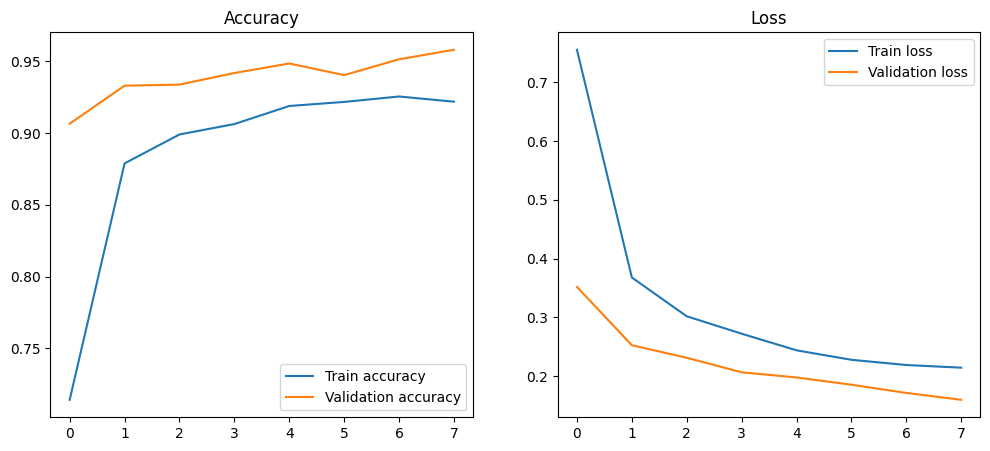

In [28]:
import matplotlib.pyplot as plt
#bibliotheque python pour les graphiques

acc = history.history['accuracy']
#recuperer les accuracy d'entrainement enregistres dans chaque epoch
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))
#creer les numeros des epoch pour l'axe horizontale graphique

plt.figure(figsize=(12, 5))
#creer la zone dans laquelle tes graphiques vont etre dessinees

plt.subplot(1, 2, 1)
#sert a choisir ou placer le graphique dans la figure

plt.plot(epochs_range, acc, label='Train accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.legend()
plt.title('Loss')

plt.savefig('/content/leaf-disease-transfer-learning/images_resultats_accuracy_loss.png')
plt.show()

In [29]:
import shutil
shutil.copy(
    "/content/drive/MyDrive/Colab Notebooks/notebook_classification.ipynb",
    "/content/leaf-disease-transfer-learning/notebook_classification.ipynb"
)

%cd /content/leaf-disease-transfer-learning
!git add .
!git commit -m "Train: premier entrainement termine, 95.8% val accuracy"
!git push

/content/leaf-disease-transfer-learning
[main aa202f3] Train: premier entrainement termine, 95.8% val accuracy
 2 files changed, 1 insertion(+), 1 deletion(-)
 create mode 100644 images_resultats_accuracy_loss.png
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 90.99 KiB | 13.00 MiB/s, done.
Total 4 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/aliciaandriantsara/leaf-disease-transfer-learning.git
   1600cdc..aa202f3  main -> main


In [30]:
#fine-tuning
#ajuste un modele deja preentraine
#s'adapter davantage aux caracteristiques specifiques des feuilles et des maladies

base_model.trainable = True
#on autorise les poids de base model de MobileNetV2 a etre modifie pendant l'entrainement

# On ne dégèle que les ~30 dernières couches (pas tout le modèle)
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompiler avec un learning rate TRÈS faible
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Couches entraînables : {sum(l.trainable for l in base_model.layers)}")

Couches entraînables : 30


In [31]:
FINE_TUNE_EPOCHS = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS
)

Epoch 1/5
199/199 ━━━━━━━━━━━━━━━━━━━━ 487s 2s/step - accuracy: 0.8175 - loss: 0.5793 - val_accuracy: 0.9279 - val_loss: 0.2096
Epoch 2/5
199/199 ━━━━━━━━━━━━━━━━━━━━ 464s 2s/step - accuracy: 0.9022 - loss: 0.2725 - val_accuracy: 0.9375 - val_loss: 0.1792
Epoch 3/5
199/199 ━━━━━━━━━━━━━━━━━━━━ 465s 2s/step - accuracy: 0.9211 - loss: 0.2197 - val_accuracy: 0.9514 - val_loss: 0.1502
Epoch 4/5
199/199 ━━━━━━━━━━━━━━━━━━━━ 492s 2s/step - accuracy: 0.9367 - loss: 0.1819 - val_accuracy: 0.9536 - val_loss: 0.1423
Epoch 5/5
199/199 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.9417 - loss: 0.1625 - val_accuracy: 0.9544 - val_loss: 0.1268
